# Week 7:  Introduction to Statistics for Data Science

Loading the data.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('business_data.csv')

df.head()

,Date,Store_Region,Promo_Strategy,Daily_Visitors,Marketing_Spend,Daily_Revenue,Customer_Satisfaction_Score
0,2025-01-01,North,Standard,4856,1145.32,9876.45,4.12
1,2025-01-02,South,Aggressive_Discount,5234,1389.76,12543.21,4.35
2,2025-01-03,East,Standard,4923,1087.54,9234.67,3.98
3,2025-01-04,West,Aggressive_Discount,5512,1456.89,13012.34,4.41
4,2025-01-05,North,Standard,4789,1234.12,10456.78,4.22


### descriptive statistics

In [ ]:
# shows all the descriptive statistics of all the numeric data column in dataset. Execpt median
desc_stats= df.describe()

#Median of all numerical data column
medians = df[['Daily_Visitors','Marketing_Spend','Daily_Revenue','Customer_Satisfaction_Score']].median()

#mode for all categorical data column
mode_reg = df['Store_Region'].mode()[0]
mode_promo = df['Promo_Strategy'].mode()[0]

In [38]:
print("Descriptive statstics:")
print('='*50)
desc_stats

Descriptive statstics:


,Daily_Visitors,Marketing_Spend,Daily_Revenue,Customer_Satisfaction_Score
count,200.000000,200.000000,200.000000,200.000000
mean,5198.810000,1328.221850,11730.125300,4.254900
std,320.571998,169.174615,1837.564176,0.201831
min,4678.000000,1045.670000,8934.560000,3.840000
25%,4912.000000,1188.835000,10123.450000,4.097500
50%,5128.500000,1289.340000,11023.450000,4.240000
75%,5514.750000,1498.980000,13678.900000,4.430000
max,5745.000000,1634.560000,15123.450000,4.610000


In [39]:
print('='*50)
print("Median of all Numerical Data columns:")
print('='*40)
print(medians)
print('='*40)
print("Mode for categorical data coclumns")
print('='*40)
print(f"Store_Region:   {mode_reg}")
print(f"Promo_Strategy: {mode_promo}")
print('='*50)



Median of all Numerical Data columns:
Daily_Visitors                  5128.50
Marketing_Spend                 1289.34
Daily_Revenue                  11023.45
Customer_Satisfaction_Score        4.24
dtype: float64
Mode for categorical data coclumns
Store_Region:   East
Promo_Strategy: Standard


Statistical Analysis:
- 'Daily Revenue':
    - Mean = 11730.12
    - Median = 11023.45
    - difference is around 700, so there is outliers, In our case there is No mega sales day happened.

- 'Marketing Spend'
    - standard deviation = 169.17
    - comparing to its mean(which is 1328), our marketing spend is reasonable, a its fine.

- 'Customer_Satisfaction_Score'
    - the mean is 4.25. which is a very good thing.
    - It means every 4.25 people out of 5 people are statisfied with our business service.

### Data Distribution Analysis

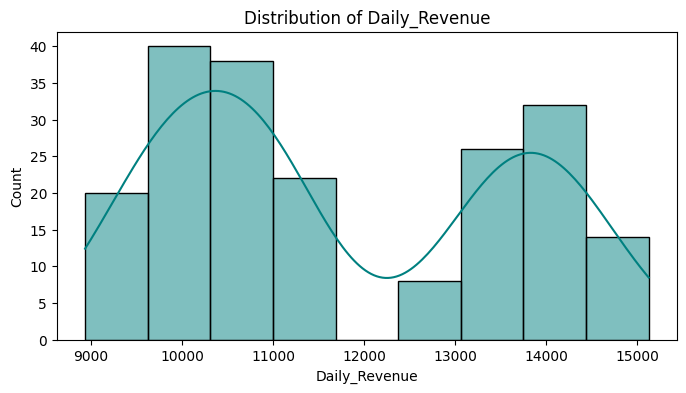

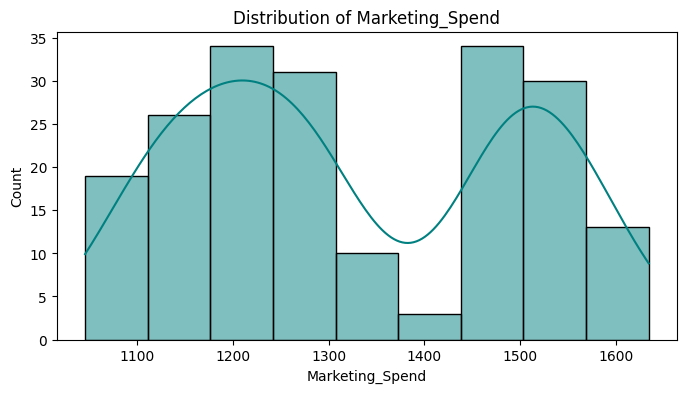

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_check = ['Daily_Revenue', 'Marketing_Spend']

for col in cols_to_check:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')
    plt.show()

We have a 'M' shaped distribution which means we have 2 different peaks, all thanks to the promo_statergy. I guess the promo Stategy worked.

Shapiro_Wilk test is a most popular test for checking Normality amoung data. 

In [6]:
from scipy.stats import shapiro

for col in cols_to_check:
    stat, p = shapiro(df[col])
    print(f'--- {col} ---')
    print(f'Statistics={stat:.3f}, p-value={p:.3f}')
    
    if p > 0.05:
        print("Result: Looks Gaussian/Normal (Fail to reject H0)")
    else:
        print("Result: Does not look Normal (Reject H0)")
    print("="*20)

--- Daily_Revenue ---
Statistics=0.891, p-value=0.000
Result: Does not look Normal (Reject H0)
--- Marketing_Spend ---
Statistics=0.916, p-value=0.000
Result: Does not look Normal (Reject H0)


It is as clear as possible, that our data is not normal. cuz of the p-values is strictly '0'

In [7]:
# Creating a new column with the log of Revenue
df['Log_Revenue'] = np.log(df['Daily_Revenue'])

# Now, run the Shapiro test on the NEW column
stat, p = shapiro(df['Log_Revenue'])
print(f"Log Revenue P-value: {p:.3f}")

Log Revenue P-value: 0.000


I tried to transform the daily revenue column with log() and create a new column.
- the log() function will transforms the data in such a way that the column should look normal
- after transformation, the p-value remains '0'. so we quit to froceing the data to be normal and use different way to work-around.

### Correlation Analysis

In [8]:
# Using 'spearman' for non-normal data
correlation = df['Marketing_Spend'].corr(df['Daily_Revenue'], method='spearman')
print(f"Spearman Correlation: {correlation:.3f}")

Spearman Correlation: 0.999


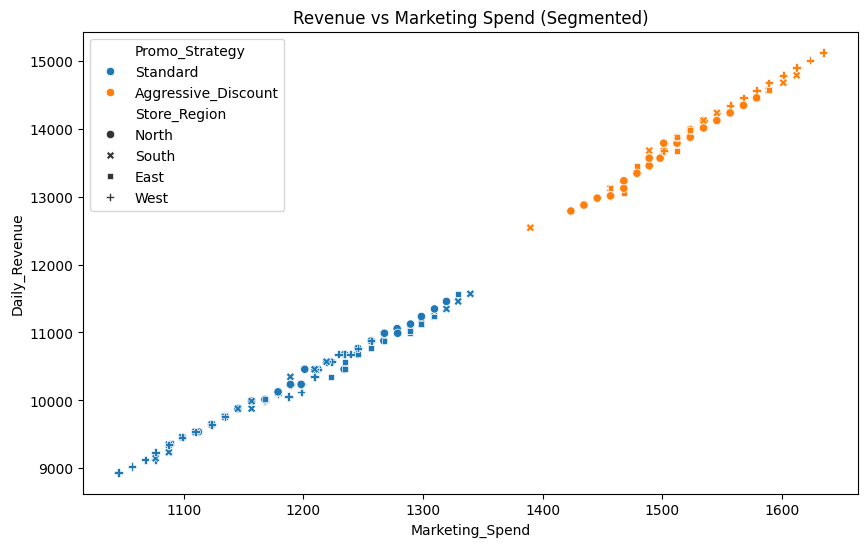

In [9]:
# This plot will show us if the "M" is caused by the Promo Strategy
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Marketing_Spend', y='Daily_Revenue', hue='Promo_Strategy', style='Store_Region')
plt.title("Revenue vs Marketing Spend (Segmented)")
plt.show()

We can clear see that the promo_statergy used is a imapctful.

we will calcualate correlation for both group.

In [11]:
standard_stgy = df[df['Promo_Strategy']== 'Standard'][['Marketing_Spend','Daily_Revenue']]
argDis_stgy = df[df['Promo_Strategy']== 'Aggressive_Discount'][['Marketing_Spend','Daily_Revenue']]

standard_stgy_corr = standard_stgy['Marketing_Spend'].corr(standard_stgy['Daily_Revenue'])
argDis_stgy_corr = argDis_stgy['Marketing_Spend'].corr(argDis_stgy['Daily_Revenue'])

print(f'Correlation of Standard Statergy: {standard_stgy_corr:.4f}')
print(f'Correlation of Aggressive Discount Statergy: {argDis_stgy_corr:.4f}')

Correlation of Standard Statergy: 0.9957
Correlation of Aggressive Discount Statergy: 0.9907


**By this we cal tell that the more the marketing spend the more the daily revenue**

### **Hypothesis Testing**

- Null hypothesis(h0): There is no real difference between the gap, it just a random gap
- Alternative Hypothesis(h1): The 'Aggressive_Discount' line is significantly higher than the 'Standard' line.

In [35]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(standard_stgy['Daily_Revenue'], argDis_stgy['Daily_Revenue'])
print(f"Mann-Whitney U P-value: {p}")

if p < 0.05:
  print("We Reject the Null Hypothesis, and Accept the Alternative Hypothesis")
else:
  print("We failed to reject  the NULL hypothesis")

print(f'U Statistic is: {stat}')

Mann-Whitney U P-value: 4.975700200680058e-33
We Reject the Null Hypothesis, and Accept the Alternative Hypothesis
U Statistic is: 0.0


By this We can Confirm that the Aggressive Discount statergy is ligit and it is Impactful for the business.

### Confidence Intervals

In [18]:
import scipy.stats as stats

for stg in ['Standard', 'Aggressive_Discount']:
  data = df[df['Promo_Strategy'] == stg]['Daily_Revenue']

  mean= np.mean(data)
  sem = stats.sem(data)   # standard error
  #calculating 95% confidence Intervals
  ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale = sem)

  print(f'-----{stg}-----')
  print(f'Average Revenue: ₹{mean:.2f}')
  print(f'95% Confidence Intervals : ₹{ci[0]:.2f} to ₹{ci[1]:.2f}')
  print(f'Margin of error :± ₹{(ci[1]-mean):.2f}\n')


-----Standard-----
Average Revenue: ₹10323.15
95% Confidence Intervals : ₹10202.56 to ₹10443.75
Margin of error :± ₹120.60

-----Aggressive_Discount-----
Average Revenue: ₹13840.59
95% Confidence Intervals : ₹13715.12 to ₹13966.05
Margin of error :± ₹125.46



Aggressive Discount strategy shows a significantly higher average revenue than Standard strategy. The non-overlapping confidence intervals indicate that the difference is statistically meaningful, and the small margins of error suggest precise estimation.


simply put: Aggressive Discount performs better in revenue generation


### Regression Analysis.

I will build a Multiple Linear regression model to predict the Daily_revenue

In [19]:
df1 = df.copy(deep=True) #a deep copy of original data.

In [24]:
#transforming data
#converting Promo_Statergy column from categorical to numerical

df1['Promo_encoded'] = df1['Promo_Strategy'].map({'Standard': 0, 'Aggressive_Discount':1})
df1.head()

,Date,Store_Region,Promo_Strategy,Daily_Visitors,Marketing_Spend,Daily_Revenue,Customer_Satisfaction_Score,Log_Revenue,Promo_encoded
0,2025-01-01,North,Standard,4856,1145.32,9876.45,4.12,9.197908,0
1,2025-01-02,South,Aggressive_Discount,5234,1389.76,12543.21,4.35,9.436935,1
2,2025-01-03,East,Standard,4923,1087.54,9234.67,3.98,9.130720,0
3,2025-01-04,West,Aggressive_Discount,5512,1456.89,13012.34,4.41,9.473653,1
4,2025-01-05,North,Standard,4789,1234.12,10456.78,4.22,9.255006,0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x = df1[['Marketing_Spend','Promo_encoded']]
y = df1['Daily_Revenue']

#Spliting the data into training and testing data
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2, random_state=2, stratify=x['Promo_encoded'])

#LinearRegression Model
lin = LinearRegression()

#Trianing the model
lin.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import r2_score

#testing the model and printing it r2_score
ypred = lin.predict(xtest)

r2score = r2_score(ytest, ypred)

print(f'{r2score:.2%}')

99.74%


Our regression model predicted 99.76% of the data right, and remaining are causd by noise.

In [34]:
print(f"Intercept: {lin.intercept_:.2f}")
print(f"Coefficients: {lin.coef_}")

Intercept: -995.86
Coefficients: [  9.42168988 529.60959444]


- *the coefficient 1*: 9.421, tells us that if we spend 1 rupee we will get 9.42 rupee as revenue.
- *the coefficient 2*: 529.6, tells us that if we use any statergy we can gain 529 rupees by spending 1 rupee.

##### I want to make a simple prediction with some values, this is like a real_world deployment kind.

In [50]:
import warnings
warnings.filterwarnings('ignore')

You can change the new_spend and new_promo(selecting either Standard(0) or Aggressive_discount(1))

In [51]:
new_spend = 1000  # What we plan to spend
new_promo = 1     # 1 for Aggressive_Discount, 0 for Standard Statergy

# 2. Reshape for the model (it expects a 2D array/list of lists)
new_data = [[new_spend, new_promo]]

# 3. Get the prediction
prediction = lin.predict(new_data)

print(f"Predicted Daily Revenue: ${prediction[0]:,.2f}\n",'='*100)

Predicted Daily Revenue: $8,955.44
